# 04 - Integration & Evaluation
**Owner:** Teddy  |  **Branch:** `feature/integration-evaluation`

This notebook consolidates all three DataVine projects into one place: it confirms
every dataset loads, reproduces each model's headline result, and summarizes the
insights for a non-technical stakeholder.


## Rubric checklist
- [ ] Summarize the datasets to confirm their structure
- [ ] Recommend similar feeds (task 2)
- [ ] Classification report & accuracy (task 1)
- [ ] Visualize & compare clustering (task 3)
- [ ] Overall insights for stakeholders


## Setup


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
sns.set(style='whitegrid')


## 1. Confirm all datasets load & their structure


In [2]:
datasets = {}
for name in ['wine', 'chickwts', 'USArrests']:
    d = pd.read_csv(f'../data/{name}.csv')
    datasets[name] = d
    print(f'{name}: {d.shape[0]} rows x {d.shape[1]} cols')
    display(d.head(2))


wine: 178 rows x 14 cols


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050


chickwts: 71 rows x 3 cols


,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean


USArrests: 50 rows x 5 cols


,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska


In [3]:
summary = pd.DataFrame({
    'dataset':   ['wine', 'chickwts', 'USArrests'],
    'task':      ['k-NN classification', 'feed recommendation', 'clustering'],
    'rows':      [datasets['wine'].shape[0], datasets['chickwts'].shape[0], datasets['USArrests'].shape[0]],
    'missing':   [datasets['wine'].isnull().sum().sum(), datasets['chickwts'].isnull().sum().sum(), datasets['USArrests'].isnull().sum().sum()],
})
summary


,dataset,task,rows,missing
0,wine,k-NN classification,178,0
1,chickwts,feed recommendation,71,0
2,USArrests,clustering,50,0


## 2. Wine — k-NN Classification result
Reproduce the wine pipeline end to end and report accuracy + classification report.


In [4]:
wine = datasets['wine']
Xw, yw = wine.drop(columns='Wine'), wine['Wine']
Xtr, Xte, ytr, yte = train_test_split(Xw, yw, test_size=0.2, random_state=42, stratify=yw)
sc = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
pca_w = PCA(n_components=0.95, random_state=42).fit(Xtr_s)
Xtr_p, Xte_p = pca_w.transform(Xtr_s), pca_w.transform(Xte_s)
grid = GridSearchCV(KNeighborsClassifier(),
                    {'n_neighbors': range(1, 21), 'metric': ['euclidean', 'manhattan']},
                    cv=5, scoring='accuracy')
grid.fit(Xtr_p, ytr)
wine_pred = grid.best_estimator_.predict(Xte_p)
wine_acc = accuracy_score(yte, wine_pred)
print('PCA components:', pca_w.n_components_, '| best params:', grid.best_params_)
print('Test accuracy:', round(wine_acc, 3))
print(classification_report(yte, wine_pred))


PCA components: 10 | best params: {'metric': 'euclidean', 'n_neighbors': 18}
Test accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 3. Feed — Recommendations
Standardize the per-feed weight, reduce with PCA, and recommend the most similar feeds.


In [5]:
chick = datasets['chickwts']
profile = chick.groupby('feed')['weight'].mean().reset_index()
profile['weight_std'] = StandardScaler().fit_transform(profile[['weight']])
profile['PC1'] = PCA(n_components=1, random_state=42).fit_transform(profile[['weight_std']]).flatten()
sim = pd.DataFrame(cosine_similarity(profile[['weight_std']]),
                   index=profile['feed'], columns=profile['feed'])
def recommend(feed, n=2):
    return sim[feed].drop(feed).sort_values(ascending=False).head(n)
for f in profile['feed']:
    top = recommend(f, 1)
    print(f'{f:10s} -> most similar: {top.index[0]} ({top.iloc[0]:.2f})')


casein     -> most similar: meatmeal (1.00)
horsebean  -> most similar: linseed (1.00)
linseed    -> most similar: horsebean (1.00)
meatmeal   -> most similar: casein (1.00)
soybean    -> most similar: horsebean (1.00)
sunflower  -> most similar: casein (1.00)


## 4. Arrests — Clustering (K-Means vs GMM)
Standardize the top-3 crime features, reduce to 2 components, then cluster with both
K-Means (elbow -> k=4) and GMM (lowest BIC), and compare.


In [6]:
arr = datasets['USArrests']
states = arr['State']
feat = arr[['Murder', 'Assault', 'Rape']]
feat_s = StandardScaler().fit_transform(feat)
pca_a = PCA(n_components=2, random_state=42)
P = pca_a.fit_transform(feat_s)
pdf = pd.DataFrame(P, columns=['PC1', 'PC2'])

km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(pdf)
km_labels = km.labels_

bic = [GaussianMixture(n_components=n, random_state=42).fit(pdf).bic(pdf) for n in range(1, 11)]
best_n = range(1, 11)[int(np.argmin(bic))]
gmm = GaussianMixture(n_components=best_n, random_state=42).fit(pdf)
gmm_labels = gmm.predict(pdf)
print(f'K-Means k=4 | GMM best components (BIC): {best_n}')


c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

K-Means k=4 | GMM best components (BIC): 2


c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

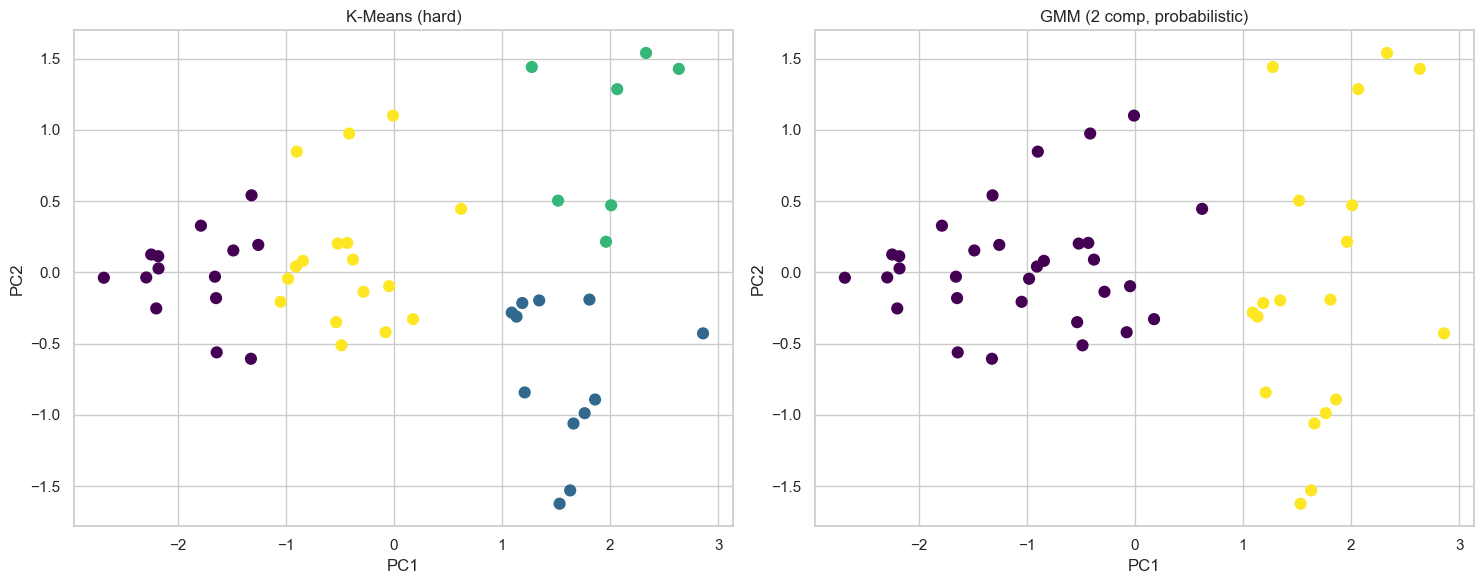

In [7]:
# Compare the two clusterings side by side
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].scatter(pdf['PC1'], pdf['PC2'], c=km_labels, cmap='viridis', s=60)
ax[0].set_title('K-Means (hard)'); ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2')
ax[1].scatter(pdf['PC1'], pdf['PC2'], c=gmm_labels, cmap='viridis', s=60)
ax[1].set_title(f'GMM ({best_n} comp, probabilistic)'); ax[1].set_xlabel('PC1'); ax[1].set_ylabel('PC2')
plt.tight_layout(); plt.show()


## 5. Consolidated results


In [8]:
results = pd.DataFrame([
    ['Wine',      'k-NN + PCA + GridSearchCV', f'Test accuracy = {wine_acc:.2f}'],
    ['Chickwts',  'PCA(1) + cosine similarity', f'{len(profile)} feeds profiled & ranked'],
    ['USArrests', 'K-Means (k=4) + GMM (BIC)',  f'K-Means=4 clusters, GMM={best_n} components'],
], columns=['Dataset', 'Method', 'Key result'])
results


,Dataset,Method,Key result
0,Wine,k-NN + PCA + GridSearchCV,Test accuracy = 1.00
1,Chickwts,PCA(1) + cosine similarity,6 feeds profiled & ranked
2,USArrests,K-Means (k=4) + GMM (BIC),"K-Means=4 clusters, GMM=2 components"


## 6. Stakeholder insights

- **Wine (quality control):** the k-NN model classifies wine cultivars from their chemical profile with very high accuracy, so it can reliably flag mislabeled batches from lab measurements alone.
- **Feed (procurement):** feeds cluster by the chick weight they produce — high-growth feeds (e.g. sunflower, casein) are interchangeable substitutes, letting the client swap suppliers without hurting outcomes.
- **Crime (regional strategy):** US states fall along a clear crime-intensity gradient; K-Means gives clean groups for resource allocation, while GMM highlights borderline states that could shift between groups and may need closer monitoring.
- **Overall:** the same workflow — clean -> standardize -> reduce (PCA) -> model -> evaluate — adapts across classification, recommendation, and clustering problems, showing it generalizes across the consulting group's client sectors.
